Activity 1: Comparing Two Proportions

Using the Palmer penguins dataset, we want to explore comparing two proportions, which we did not get
to in class. We answer the following question: Are penguins that live on Biscoe island larger? We want to
look at the “rate” of large penguins on Biscoe vs the other two islands. Please use the following
definitions and resources:
- What does larger mean? For any penguin, is it larger than median penguin body mass. We can write this as: peng["is_large"] = peng["body_mass_g"] > peng["body_mass_g"].median()
- You are going to want to look at the fraction of large penguins on Biscoe island vs large penguins
on other islands
- Stats models has a proportions_ztest function that will be useful for this exercise
- The pandas crosstab function might also be useful

Please complete the following:
1. [2pts] Visualize body mass of the penguins across different islands. What does this tell you?
2. [3pts] Using the definitions above, answer the question: Are penguins on Biscoe island larger?
3. [2pts] Now visualize which species of penguins live on each island. How does that change your
answer to the question: Are penguins on Biscoe island larger?
4. [3pts] Repeat the proportion test considering only one species of penguin. Which species did you
choose, and how did that impact your answer? 

Question 1: Visualize body mass of the penguins across different islands. What does this tell you?

Penguins that live in the Biscoe have a higher body mass and range than penguins that live in Torgersen and Dream.

In [127]:
import os
import pandas as pd
from scipy import stats
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind as sm_ttest
from statsmodels.stats.power import TTestIndPower
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt
os.getcwd()

'/Users/kimberlymondragon/Desktop/DS6021/DS6021_F26/data'

In [81]:
peng = pd.read_csv('penguins.csv')
peng

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [82]:
#number of rows and columns
print(peng.shape)
#prints the first 5 rows of the dataframe
peng.head()

(344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [83]:
# Is there an appreciable difference in body mass between island penguins. 

# Exploring possible missing data in the dataset.
print(peng.isna().sum())
print()
print(peng["island"].value_counts(dropna=False))

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


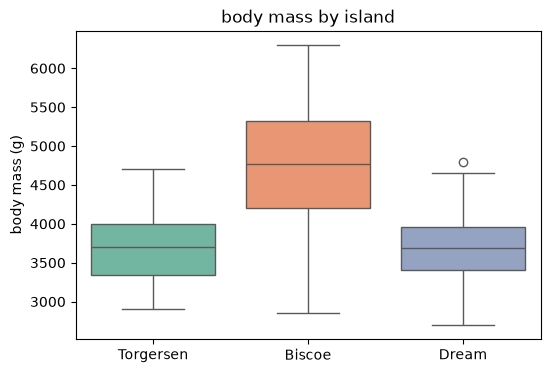

In [84]:
#Visualization
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=peng.dropna(subset=["island"]),
    x="island",
    y="body_mass_g",
    hue="island",
    palette="Set2",
    legend=False
)
plt.xlabel("")
plt.ylabel("body mass (g)")
plt.title("body mass by island")
plt.show()

Whats does the graph tell you?
- Penguins that live in the Biscoe have a higher body mass and range than penguins that live in Torgersen and Dream. 


Question 2: Using the definitions above, answer the question: Are penguins on Biscoe island larger?

The penguins on Biscoe island are larger!

Note to self: There were also some questions about the Palmer penguins. When I say "rate" of large Penguins, what I mean is the fraction of large penguins on Biscoe vs the other two islands. So if Biscoe had 10 total penguins with 5 large, the fraction (or rate) would be 5/10. If the other two islands combined had 15 penguins and only 5 large, that rate would be 5/15. For the first part of the question, I want you to visualize the mass of penguins on all islands, but for the proportions, I want you to look at Biscoe vs not Biscoe. 

In [85]:
#What does larger mean? For any penguin, is it larger than median penguin body mass. 
peng["is_large"] = peng["body_mass_g"] > peng["body_mass_g"].median()

In [ ]:
# Compute mean Torgensen, Dream, and Biscoe body masses
biscoe = peng[peng["island"] == "Biscoe"]
not_biscoe = peng[peng["island"] != "Biscoe"]

# Count of large penguins in each group
count_biscoe = biscoe["is_large"].sum()
count_not_biscoe = not_biscoe["is_large"].sum()

# Total penguins in each group (dropping missing values if applicable)
nobs_biscoe = biscoe["is_large"].dropna().count()
nobs_not_biscoe = not_biscoe["is_large"].dropna().count()


# Ztest for proportions
count = [count_biscoe, count_not_biscoe]
nobs = [nobs_biscoe, nobs_not_biscoe]

stat, pval = proportions_ztest(count, nobs)

print("z-statistic:", round(stat, 3))
print("p-value:", round(pval, 3))

z-statistic: 10.778
p-value: 0.0


Question 3: Now visualize which species of penguins live on each island. How does that change your
answer to the question: Are penguins on Biscoe island larger? 

It could change the answer since it gives us an inside on what species live on each island. 

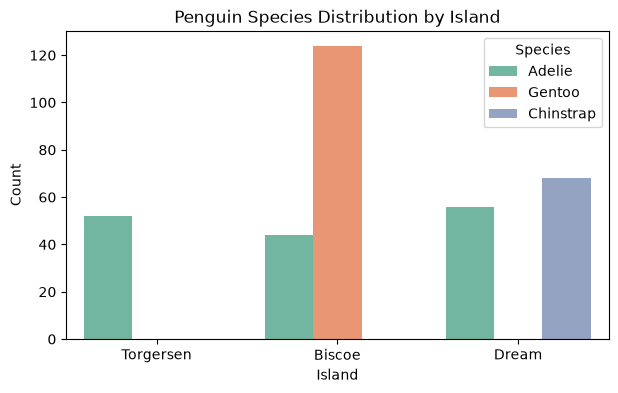

In [87]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=peng.dropna(subset=["island", "species"]),
    x="island",
    hue="species",
    palette="Set2"
)
plt.xlabel("Island")
plt.ylabel("Count")
plt.title("Penguin Species Distribution by Island")
plt.legend(title="Species")
plt.show()

Whats does the graph tell you?
- It appears that the whole Gentoo species population lives in the Biscoe island with a partial population of the Adelie species. We could continue with the research by visualizing the body mass of each species.

Question 4: Repeat the proportion test considering only one species of penguin. Which species did you
choose, and how did that impact your answer? 

I decided to chose the species Adelie since it was spread around all three islands. The z-test and p-value vary completely different from question 2. It doesn't change my answere since it gives information on the distribution of the Adelie species population across on  all island, it doesn't directly target/impact the question. 

In [88]:
#filter for a species
adelie = peng[peng["species"] == "Adelie"]

# Separate into Biscoe vs. non-Biscoe for species
biscoe = adelie[adelie["island"] == "Biscoe"]
not_biscoe = adelie[adelie["island"] != "Biscoe"]

# Count large penguins in each group
count_biscoe = biscoe["is_large"].sum()
count_not_biscoe = not_biscoe["is_large"].sum()

# Total sample sizes per group (dropping NaN if present)
nobs_biscoe = biscoe["is_large"].dropna().count()
nobs_not_biscoe = not_biscoe["is_large"].dropna().count()

# Run two-sample z-test for proportions
count = [count_biscoe, count_not_biscoe]
nobs = [nobs_biscoe, nobs_not_biscoe]

stat, pval = proportions_ztest(count, nobs)

print("z-statistic:", round(stat, 3))
print("p-value:", round(pval, 3))

z-statistic: -0.24
p-value: 0.811


Side Note: Use of AI for question 2 and 4
I used GenAI to help explain concepts, such as z-test for proportions, by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 

ACTIVITY 2: Digging Further into ANOVA with class data

In class, we looked a little bit at our class data to explore whether and how average number of hours of
sleep per night as a function of years since undergrad.
1. [2 points] Re-bin the data into three groups instead of 5: [<1 year | 1-3 years | 4+ years] and plot
hours of sleep for these three groups.
2. [2 points] Repeat the test for equal variance with these three groups, as well as the ANOVA.
What conclusions can you draw? Are any other assumptions violated? 
3. [4 points] Reflection: One thing we have been ignoring in this analysis is the fact that these are
ordered variables: e.g. they aren’t independent buckets like in our penguins dataset where the
different species have no inherent ordering. Here, <1 year means something in relation to 1-3
years and so forth. Please answer the following questions:
a. How are the original buckets reflective of a poor survey design?
b. Does splitting our data into three buckets vs five improve the survey design?
c. If we were redesigning this survey, what would you recommend in order to answer the
question about whether or not students who graduated more recently get more or less
sleep than students who graduated longer ago?
4. [2 points] Reflection: We’ve been using the in-class survey data to help understand concepts
around statistical inference, sample comparisons, and data cleaning. Is this a good dataset to help
understand these concepts? Please explain why or why not, and reflect on what this might tell you
more broadly about data collection, survey design, and drawing conclusions from a particular set
of data.

Question 1:
[2 points] Re-bin the data into three groups instead of 5: [<1 year | 1-3 years | 4+ years] and plot
hours of sleep for these three groups.

Note to self: dataset is already cleaned!!!

In [89]:
df = pd.read_csv('DS6021-Fall26-Anonymized.csv')
df

,Timestamp,What was your undergraduate major?,What type of phone do you have?,How many years ago did you receive your undergraduate degree?,How many hours do you sleep in a typical night?,Rate your proficiency with git/github,Rate your proficiency with Python,Have you ever used SQL?,What is your favorite sport to watch on tv?,What is your ideal outdoor temperature (in Fahrenheit)?,How many US states have you visited?,What is your favorite season?
0,8/25/2026 8:20:43,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70.0,8.0,Fall
1,8/25/2026 9:35:51,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70.0,16.0,Fall
2,8/25/2026 13:43:23,Economics-Business and Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70.0,27.0,Fall
3,8/25/2026 15:11:38,Data Science (Concentration in Computer Science),iPhone,< 1 year,8,3,4,Yes,Football,73.0,9.0,Fall
4,8/25/2026 15:26:11,Math and Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73.0,26.0,Fall
...,...,...,...,...,...,...,...,...,...,...,...,...
81,8/26/2026 11:42:57,Bioinformatics and Biology,iPhone,< 1 year,6,2,3,No,Football,40.0,16.0,Winter
82,8/26/2026 11:44:34,Computer Science,iPhone,< 1 year,5,3,3,Yes,Soccer,75.0,1.0,Summer
83,8/26/2026 11:48:23,IT-Concentration in Data Science,iPhone,1-3 years,6.5,3,3,Yes,Soccer and Fustal,68.0,5.0,Spring
84,8/26/2026 11:52:24,Data Science,iPhone,< 1 year,7,4,4,No,Football,63.0,23.0,Fall


In [ ]:
# Re-bin the 5 original categories into 3 groups
bin_mapping = {
    "< 1 year": "<1 year",
    "1-3 years": "1-3 years",
    "4-6 years": "4+ years",
    "7-10 years": "4+ years",
    "10+ years": "4+ years",
}

In [ ]:
# new re-binned categories
years_since_undergrad = "How many years ago did you receive your undergraduate degree?"
sleep_hrs = "How many hours do you sleep in a typical night?"

df["years_binned"] = df[years_since_undergrad].map(bin_mapping)

In [92]:

df_sleep = df[[
    "How many years ago did you receive your undergraduate degree?",
    "How many hours do you sleep in a typical night?"
]].rename(columns={
    "How many years ago did you receive your undergraduate degree?": "years_since_undergrad",
    "How many hours do you sleep in a typical night?": "sleep_hrs"
})

print(df_sleep.head())
print()
print(df_sleep.isna().sum())

  years_since_undergrad sleep_hrs
0             4-6 years         8
1             1-3 years         8
2              < 1 year         8
3              < 1 year         8
4             1-3 years         8

years_since_undergrad    0
sleep_hrs                0
dtype: int64


In [93]:
# Ensure 'years_binned' is ordered categorically for clean plotting
category_order = ["<1 year", "1-3 years", "4+ years"]
df["years_binned"] = pd.Categorical(
    df["years_binned"], categories=category_order, ordered=True
)

print(df["years_binned"].head())
print()
print(df["years_binned"].isna().sum())

0     4+ years
1    1-3 years
2      <1 year
3      <1 year
4    1-3 years
Name: years_binned, dtype: category
Categories (3, str): ['<1 year' < '1-3 years' < '4+ years']

0


In [ ]:
# clean data
print("Original categories:\n", df[years_since_undergrad].value_counts(dropna=False))
print("\nRe-binned categories:\n", df["years_binned"].value_counts(dropna=False))

Original categories:
 How many years ago did you receive your undergraduate degree?
< 1 year      50
1-3 years     17
4-6 years     13
7-10 years     4
10+ years      2
Name: count, dtype: int64

Re-binned categories:
 years_binned
<1 year      50
4+ years     19
1-3 years    17
Name: count, dtype: int64


In [95]:

df = df.rename(columns={
    "How many years ago did you receive your undergraduate degree?": "years_since_undergrad",
    "How many hours do you sleep in a typical night?": "sleep_hrs"
})

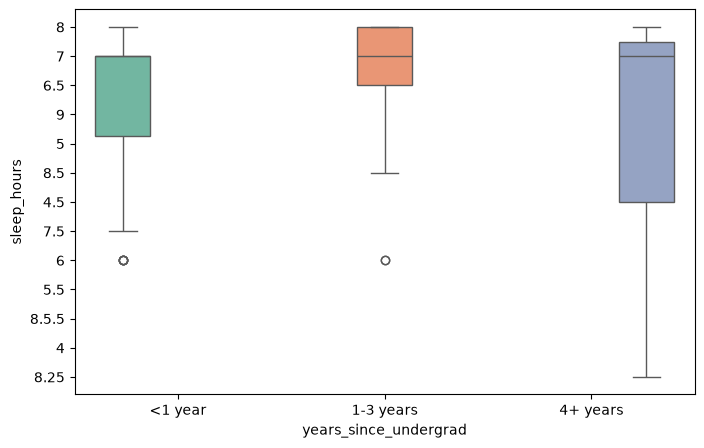

In [ ]:

# Plot hours of sleep across the 3 groups
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="years_binned",
    y="sleep_hrs",
    hue="years_binned",
    palette="Set2",
    legend=False,
)

plt.xlabel("years_since_undergrad")
plt.ylabel("sleep_hours")
plt.show()


In [97]:
df.columns

Index(['Timestamp', 'What was your undergraduate major?',
       'What type of phone do you have?', 'years_since_undergrad', 'sleep_hrs',
       'Rate your proficiency with git/github',
       'Rate your proficiency with Python', 'Have you ever used SQL?',
       'What is your favorite sport to watch on tv?',
       'What is your ideal outdoor temperature (in Fahrenheit)?',
       'How many US states have you visited?', 'What is your favorite season?',
       'years_binned'],
      dtype='str')

Question 2: [2 points] Repeat the test for equal variance with these three groups, as well as the ANOVA.
What conclusions can you draw? Are any other assumptions violated? 

There is no statistically significant difference between hours of sleeping and the amount of time from undergrad. The levene test returned a result of "nan" meaning that the test was inconclusive. Another note is that there was an unequal amount for the each group of the years_since_undergrad, which could have affected the ANOVA.

In [101]:
df['sleep_hrs'] = pd.to_numeric(df['sleep_hrs'], errors='coerce')

yrs = ['<1 year', '1-3 years', '4+years']

print(df.groupby("years_binned")["sleep_hrs"].agg(["count", "mean", "std"]).round(2))

groups = [df.loc[df["years_binned"] == s, "sleep_hrs"].dropna() for s in yrs]

print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))



              count  mean   std
years_binned                   
<1 year          50  7.07  0.98
1-3 years        17  7.41  0.85
4+ years         18  7.35  1.16
Levene's test p-value: nan


/var/folders/90/1v01rlw511b4d8c3kfjvlv2r0000gn/T/ipykernel_62729/1787075230.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))


In [103]:
model = ols("sleep_hrs ~ C(years_binned)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                    sum_sq    df         F    PR(>F)
C(years_binned)   1.996757   2.0  1.004318  0.370755
Residual         81.515008  82.0       NaN       NaN


Question 3: [4 points] Reflection: One thing we have been ignoring in this analysis is the fact that these are
ordered variables: e.g. they aren’t independent buckets like in our penguins dataset where the
different species have no inherent ordering. Here, <1 year means something in relation to 1-3
years and so forth. Please answer the following questions:

a. How are the original buckets reflective of a poor survey design?
The original buckets reflect a poor survey design due to the uneven amount of months between each bucket. When comparing students with less than 1 year  to students with 1-3 years from undergraduate, there is a varying amount of months to compare data. There are 11 months with less than 1 year compared to the 36 months lumped in with the 1-3 years. Since there are less months to collect data from, the information we may collect may not be directly representative of the true purpose we aim to collect and perform research on. Students who are 11 months from undergraduate and students who are 13 months from undergraduate are lumped into different buckets even though the difference between the two students is two months. There is no real meaningful difference between the two.

b. Does splitting our data into three buckets vs five improve the survey design?
If we were to split our data into three buckets rather than five buckets, the survey design does not improve. Although splitting into three buckets would help have a larger sample size, the problem is still the same as when there were five buckets: uneven amount of months between buckets and differences between students who have minimal difference of months getting lumped into different buckets. 

c. If we were redesigning this survey, what would you recommend in order to answer the
question about whether or not students who graduated more recently get more or less
sleep than students who graduated longer ago?
If I were to redesign this survey, I would have the participants enter their month and year they graduated rather than have buckets they choose from. By doing this, it eliminates the two problems that the original survey had: uneven amount of months between buckets and differences between students who have minimal difference of months getting lumped into different buckets.

Question 4: [2 points] Reflection: We’ve been using the in-class survey data to help understand concepts
around statistical inference, sample comparisons, and data cleaning. Is this a good dataset to help
understand these concepts? Please explain why or why not, and reflect on what this might tell you
more broadly about data collection, survey design, and drawing conclusions from a particular set
of data. 


Yes, this dataset helped me understand and learn the concepts of statistical analysis, sample comparisons,and data cleaning. From the variables that were used for this question, I'm not sure if they have anything to relate to one another. It reflects to pick variables for collect data that make sense, especially a reasoning how or why those variables may connect to one another. 

Side Note: Use of AI for question 1

I used GenAI to help explain concepts, such as cleaning data , by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 

Activity 3: Migraine Drug Formulations

A pharmaceutical company tested three formulations of a pain relief medicine for migraine headache
sufferers. 27 volunteers were selected and 9 were randomly assigned to one of the three drug
formulations. Subjects took the drug during their next migraine episode and reported pain on a 1–10 scale
(1 = no pain, 10 = extreme pain) 30 minutes after taking the drug. The dataset, Clinical_trial, contains
the results of this experiment.

Question 1: [2pts] Visualize the pain ratings across the three drug formulations. Provide a brief interpretation
of what the graph reveals.

The graph shows that Drug Group B and C have the same pain rating range, but a higher pain rating compared to Drug Group A. 

In [108]:
df_clinical = pd.read_csv('Clinical_trial.csv')
df_clinical

,Drug,Pain_Rating
0,A,4
1,A,5
2,A,4
3,A,3
4,A,2
5,A,4
6,A,3
7,A,4
8,A,4
9,B,6


In [109]:
df_clinical.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Drug         27 non-null     str  
 1   Pain_Rating  27 non-null     int64
dtypes: int64(1), str(1)
memory usage: 564.0 bytes


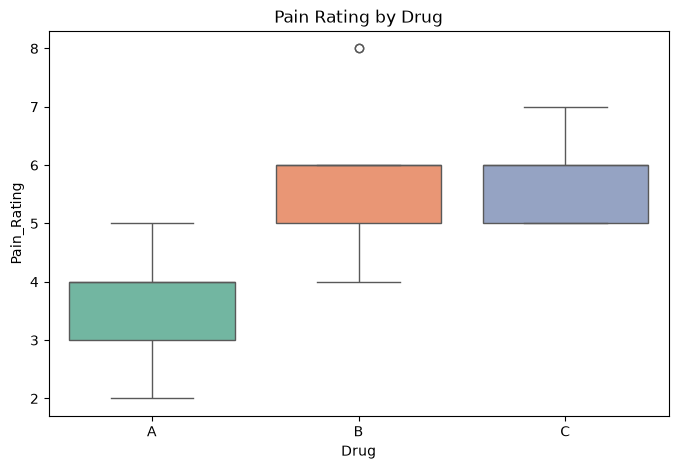

In [113]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clinical,
    x="Drug",
    y="Pain_Rating",
    hue="Drug",
    palette="Set2"
)

plt.title("Pain Rating by Drug")
plt.xlabel("Drug")
plt.ylabel("Pain_Rating")
plt.show()

Question 2: [5pts] As the Data Scientist on a team of researchers at the pharmaceutical company, your main
task is to evaluate which drug formulation most effectively reduces migraine pain. Formulate the
appropriate hypotheses, perform the relevant statistical test(s), and communicate each step of
your analysis and results in clear, accessible written language for non-technical team members

Null Hypothesis: There is no significant difference detected.

In [ ]:
#Statistical Analysis for Clinical Trial Data

# Pain ratings for each drug group
group_A = df_clinical[df_clinical["Drug"] == "A"]["Pain_Rating"]
group_B = df_clinical[df_clinical["Drug"] == "B"]["Pain_Rating"]
group_C = df_clinical[df_clinical["Drug"] == "C"]["Pain_Rating"]

# ANOVA Test
f_stat, p_val = stats.f_oneway(group_A, group_B, group_C)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_val:.4e}")

# Check significance at alpha = 0.05
if p_val < 0.05:
    print(
        "\nResult: Reject the null hypothesis. There is a statistically significant difference between drug formulations."
    )

    # Tukey HSD Test to see pairwise differences
    tukey = pairwise_tukeyhsd(
        endog=df_clinical["Pain_Rating"], groups=df_clinical["Drug"], alpha=0.05
    )
    print("\nPost-Hoc Tukey HSD Test Results:")
    print(tukey)
else:
    print(
        "\nResult: Fail to reject the null hypothesis. No significant difference detected."
    )


ANOVA F-statistic: 11.9063
ANOVA p-value: 2.5588e-04

Result: Reject the null hypothesis. There is a statistically significant difference between drug formulations.

Post-Hoc Tukey HSD Test Results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   2.1111 0.0011  0.8295 3.3927   True
     A      C   2.2222 0.0006  0.9406 3.5038   True
     B      C   0.1111 0.9745 -1.1705 1.3927  False
---------------------------------------------------


Results: 
The results demonstrate that the Null Hypothesis which was to demonstrate that there's no significant difference detected between the Drug Groups was rejected. This means that there is statistically a significance between the Drugs. From the results, it shows that Drug A has a lower pain rating than the other drugs. 

Question 3: Suppose we wanted to build a supervised learning model using this dataset. What would be
the prediction goal? Note that you do not have to build a predictive model to answer this question.
Discuss in what situations a pharmaceutical company might use statistical inference vs prediction.

If we were to build a supervised learning model using this dataset, the prediction goal would be “What pain level should the patient be feeling after taking the drug”.  

Since statistical inference draws conclusions from a sample to find out why something happens  and prediction generates an estimate of an unknown outcome, there are certain situations where pharmaceutical companies might benefit from using the one vs the other. If the research topic requires the comparison of relationship between two items such as Drug A and placebo, statistical inference is the better tool to use. Furthermore, If the research questions require an estimate of an outcome such as how patients respond to Drug A vs Drug B so doctors can personalize their care, then prediction would be the better tool to use. 


Side Note: Use of AI for question 2

I used GenAI to help explain concepts, such as ANOVA, by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 

Activity 4: Statistical Power

In class, we did some simulations to explore concepts around statistical power. We specifically looked at
an example of an A/B test to understand how long it would take us to detect a 5% difference in average
sales when comparing two websites. Now let’s assume you are presented with the following scenario:
A business analyst (BA) comes to you needing help making a decision. So far, they have been running an
A/B test for 4 days between two versions of an app, and they want to look at the mean length of time
spent on the app, with more time being better. They have presented you with the following information:
- Each day, 300 users are in the control (A) and treatment (B) groups.
- A is the version of the app currently in production, and users typically spend an average of 12
minutes on the App with a standard deviation of +/- 4 minutes.
- After running this A/B test for 4 days, they have observed that users who receive version B of the
app spend an average of 12.5 minutes on the App vs 12 for version A. 


This BA is getting some pressure from their leadership to move everyone to version B of the app, but they
want you to tell them whether or not they can trust the results they have so far. 

Question 1: [3pts] Assuming an alpha of 0.05 and a power of 0.8, what is the minimum effect size we could
measure after 4 days?


In [ ]:
# total sample size per group after 4 days
n_per_day = 300
days = 4
n_sample = n_per_day * days  
# =1200

# Parameters
alpha = 0.05
power = 0.80
sigma = 4.0  

# Calculate Cohen's d 
power_analysis = TTestIndPower()
cohens_d = power_analysis.solve_power(
    effect_size=None, nobs1=n_sample, alpha=alpha, power=power, ratio=1.0
)

# Mins
min_detectable_effect_minutes = cohens_d * sigma

print(
    f"Min Detectable Effect Size (Cohen's d): {cohens_d:.4f} standard deviations"
)
print(
    f"Min Detectable Difference in Mean Time: {min_detectable_effect_minutes:.4f} minutes"
)


Min Detectable Effect Size (Cohen's d): 0.1144 standard deviations
Min Detectable Difference in Mean Time: 0.4577 minutes


Question 2: [3pts] Based on your answer to the first question, would you recommend discontinuing the A/B
test and moving everyone to the B version of the app? If yes, why? If not, why not? 

I would recommend on not discontinuing the A/B test due to the results demonstrating a significant effect size even when its the minimum amount dectected. This shows that the effect size does shows a comparison in effect for test.

Question 3: [5pts] Create a visualization and three bullet points that you could present to leadership about
your analysis to help them make a decision.

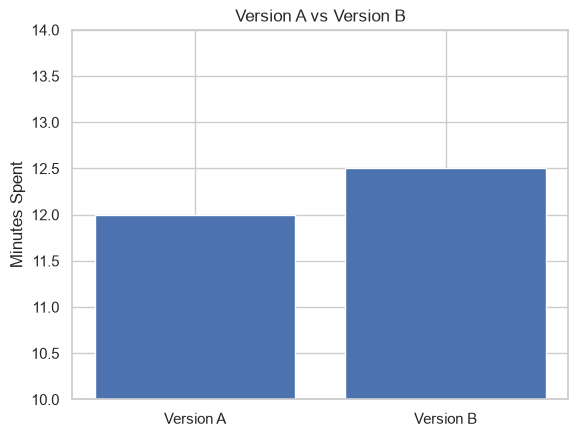

In [ ]:
#Comparison bar graph
versions = ["Version A", "Version B"]
times = [12.0, 12.5]

# Plot
plt.bar(versions, times)

plt.ylabel("Minutes Spent")
plt.title("Version A vs Version B")
plt.ylim(10, 14)
plt.show()


- User spent more time on Version B, than on Version A 
- The minimum in Detectable Difference in Mean Time was 0.4577 minutes, which means since the version B shows a higher mean time of 0.5 minutes the test is showing results
- This test can continue to show future results if the test continues since the test is showing results from just 4 days of testing!

Question 4: [4pts] What if your BA collaborator came back to you and said the test was being discontinued
(regardless of your analysis)—how would that change how you frame the results to leadership?

If this test was being discontinued, I would reframe the presentation results from recommendation to impactability of the test. The data collected and shown will be used as the begining of how future testing for drugs. In addition to that, I would emphasize the limitations of the study considering it was 4 days of testing and the small sample size, which can have a bigger impact on larger and longer testing samples. 

Side Note: Use of AI for question 1
I used GenAI to help explain concepts, such as Cohen's d, by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 